In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
import timm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class PlayingCardsDataset(Dataset):
    def __init__(self, data_directory, transforms=None):
        super().__init__()
        self.data = ImageFolder(data_directory, transform=transforms)
    def __len__(self):
        return len(self.data)
    def __getitem__(self, index):
        return self.data[index]
    
    @property
    def classes(self):
        return self.data.classes

In [3]:
data = PlayingCardsDataset('C:/Python/Card_Image_Classification/train')

In [4]:
len(data)

7624

In [5]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [6]:
data = PlayingCardsDataset('C:/Python/Card_Image_Classification/train', transforms=transform)

In [7]:
dataloader = DataLoader(data, batch_size=56, shuffle=True)

In [8]:
class SimpleCardClassifier(nn.Module):
    def __init__(self, num_classes=53):
        super(SimpleCardClassifier, self).__init__()
        self.base_model = timm.create_model(model_name='efficientnet_b0', pretrained=True)
        enet_out_size = self.base_model.classifier.in_features
        self.classifier = nn.Linear(enet_out_size, num_classes)
        self.feature = nn.Sequential(*list(self.base_model.children())[:-1])
    def forward(self, x):
        x = self.feature(x)
        x = self.classifier(x)
        return x

In [9]:
model = SimpleCardClassifier(num_classes=53)
model = model.to(device)

In [10]:
for image, label in dataloader:
    break


In [11]:
image.shape

torch.Size([56, 3, 128, 128])

In [12]:
label

tensor([38,  2, 49, 27, 27,  8, 18, 51, 32, 50, 50, 15, 42,  4, 12, 33, 18,  4,
         2, 10, 32, 35, 24, 16, 42, 22, 37,  5, 28, 39, 31, 19, 17, 43, 52, 11,
        35,  2, 18, 24,  0, 36,  9, 46,  8,  7, 29, 26, 34, 16, 37, 38, 39, 44,
        44, 49])

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [17]:
train_directory = "C:/Python/Card_Image_Classification/train"
valid_directory = "C:/Python/Card_Image_Classification/valid"
test_directory = "C:/Python/Card_Image_Classification/test"

train_data = PlayingCardsDataset(data_directory=train_directory,transforms=transform)
valid_data = PlayingCardsDataset(data_directory=valid_directory, transforms=transform)
test_data = PlayingCardsDataset(data_directory=test_directory, transforms=transform)

train_loader = DataLoader(train_data, batch_size=56, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=56, shuffle=True)
test_loader = DataLoader(test_data, batch_size=56, shuffle=False)


In [18]:
epochs = 100
train_losses, valid_losses = [], []
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc='Training loop'):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss+= loss.item()*images.size(0)
    train_loss = running_loss/len(train_loader.dataset)
    train_losses.append(train_loss)


    model.eval()
    running_loss = 0.0
    with torch.inference_mode():

        for images, labels in tqdm(valid_loader, desc='Validation loop'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()*images.size(0)

    valid_loss = running_loss/len(valid_loader.dataset)
    valid_losses.append(valid_loss)
    print(f"epoch = {epoch+1}/{epochs}, train loss = {train_loss}, validation loss = {valid_loss}")




Validation loop: 100%|██████████| 5/5 [00:02<00:00,  2.10it/s]


epoch = 1/100, train loss = 2.6433385980842248, validation loss = 1.6387953182436386


Validation loop: 100%|██████████| 5/5 [00:01<00:00,  2.74it/s]


epoch = 2/100, train loss = 1.4687823277955792, validation loss = 1.1119737701595953


Validation loop: 100%|██████████| 5/5 [00:01<00:00,  2.70it/s]


...

epoch = 98/100, train loss = 0.019004805549652563, validation loss = 0.13835071273991523


Validation loop: 100%|██████████| 5/5 [00:01<00:00,  3.05it/s]


epoch = 99/100, train loss = 0.009226337680310837, validation loss = 0.21537223269960862


Validation loop: 100%|██████████| 5/5 [00:01<00:00,  3.02it/s]

epoch = 100/100, train loss = 0.07712634110413194, validation loss = 0.2391376721690286


C:\Users\Sujith\AppData\Local\Temp\ipykernel_54412\3977670393.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


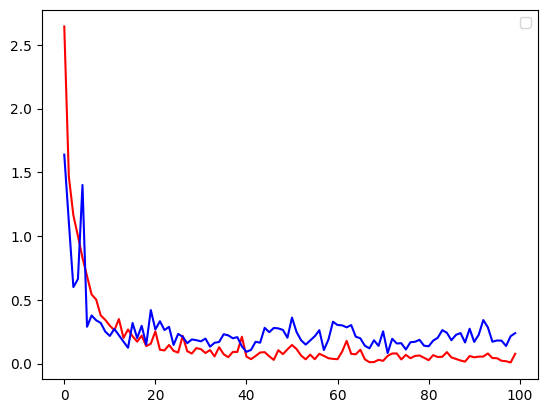

In [19]:
plt.plot(train_losses, color= 'r')
plt.plot(valid_losses, color='b')
plt.legend()
plt.show()

Training Data: 100%|██████████| 137/137 [00:15<00:00,  9.03it/s]


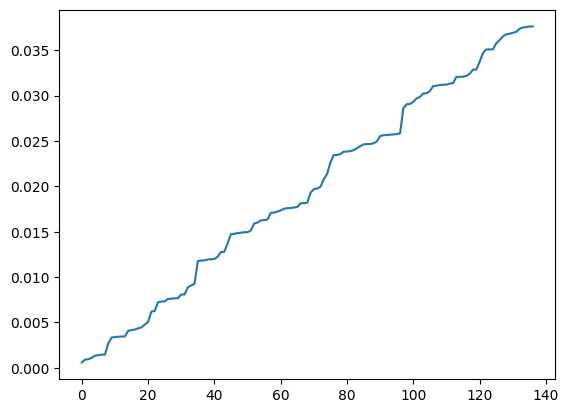

In [20]:
losses = []
with torch.no_grad():
    model.eval()
    running_loss=0.0
    for image_train, label_train in tqdm(train_loader, desc='Training Data'):
        image_train, label_train = image_train.to(device), label_train.to(device)
        outputs = model(image_train)
        loss = criterion(outputs, label_train)
        running_loss += loss.item()*image_train.size(0)
        losses.append(running_loss/len(train_loader.dataset))

plt.plot(losses)

In [64]:
i, l = train_data[493]

In [65]:
i = i.unsqueeze(0).to(device)

In [69]:
l

3

In [67]:
model.eval()
with torch.inference_mode():
    output = model(i)
output.argmax()

tensor(3, device='cuda:0')

In [71]:
torch.save(obj=model.state_dict(),f='C:/Python/CardClassificationModel.pt')